In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pickle 

# Set global font to Helvetica
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.size'] = 15 

/tmp/ipykernel_10263/1707486459.py:29: UserWarning: The following kwargs were not used by contour: 'edgecolor'
  c = ax.contourf(ts,fs,PSD,levels=levels, vmin=levels.min(), vmax=levels.max(), cmap='magma', edgecolor=None)
/tmp/ipykernel_10263/1707486459.py:31: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in c.collections:
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


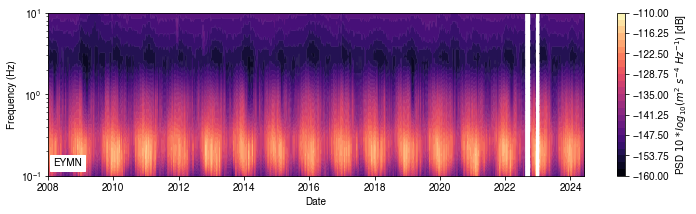

In [ ]:
# Get seismic spectra


# open a file, where you stored the pickled data
filename_list = [
            #  './PSDs/PSD_CN_SADO_BHZ_20080101_20240601_dt8days.pkl',
            #  './PSDs/PSD_US_ERPA_BHZ_20080101_20240601_dt8days.pkl',
             './PSDs/PSD_US_EYMN_BHZ_20080101_20240601_dt8days.pkl',
             ]
sta = 'US.EYMN'

# Initialize figure
fig = plt.figure(figsize=(12,3))

ipl = 0
for filename in filename_list:
    ipl = ipl + 1
    # Load pkl file
    with open(filename, 'rb') as file: 
        data_PSDs = pickle.load(file)

    ts = data_PSDs['ts']
    fs = data_PSDs['fs']
    PSD = data_PSDs['PSD']

    # Plot spectrogram of seismic noise
    ax = plt.subplot(len(filename_list),1,ipl)
    levels = np.linspace(-160,-110,25)
    c = ax.contourf(ts,fs,PSD,levels=levels, vmin=levels.min(), vmax=levels.max(), cmap='magma', edgecolor=None)
     # Add thin contour lines with matching colors
    for collection in c.collections:
        collection.set_edgecolor(collection.get_facecolor())
        collection.set_linewidth(0.5)  # Adjust linewidth as needed
    ax.set_yscale('log')
    ax.set_ylabel('Frequency (Hz)')
    if ipl==len(filename_list):
        ax.set_xlabel('Date')
    ax.set_ylim(1/10,10)

    ax.text(0.01, 0.06, data_PSDs['station'], transform=ax.transAxes,
            bbox=dict(boxstyle='square,pad=.3',facecolor='w', edgecolor='w'))
    # ax.annotate(data_PSDs['station'], (0.02, 0.05), xycoords='axes fraction')

# fig.subplots_adjust(right=0.83)
# cbar_ax = fig.add_axes([0.85, 0.125, 0.02, 0.33])
# fig.colorbar(c, cax=cbar_ax)
cb = plt.colorbar(c)
cb.set_label(r'PSD $10*log_{10}(m^2 \,\, s^{-4} \,\, Hz^{-1})$ [dB]')

plt.savefig('./figs/b2_spectrograms_'+sta+'.pdf',bbox_inches="tight")

    


/tmp/ipykernel_10263/4248118622.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10')
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


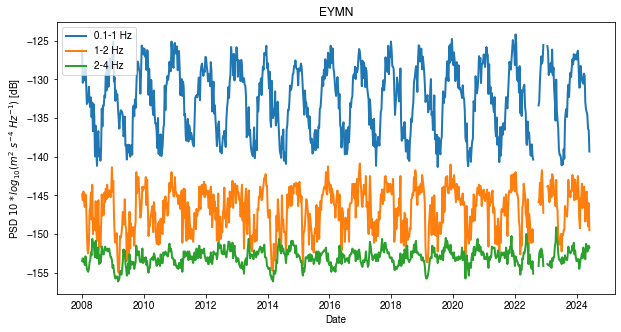

In [ ]:
import matplotlib.cm as cm

# Calculate power within frequency band

# Define fmin and fmax
# fmin = 0.5 #1/3
# fmax = 2 #1/0.65
# fmin = 0.2*2
# fmax = 0.4*2
# fmin = 1/10
# fmax = 1
# fmin = 1
# fmax = 2
fbounds_list = [
            [0.1, 1],
            [1, 2],
            [2, 4],
            ]

# filename = './PSDs/PSD_US_ERPA_BHZ_20080101_20240601_dt8days.pkl'

for filename in filename_list:

    # Initialize figure
    fig = plt.figure(figsize=(10,5))
    ax = plt.axes()

    cmap = cm.get_cmap('tab10')
    # rgb = cmap(np.linspace(0,1,len(station_list)))
    rgb = cmap(np.linspace(0,1,10))
    ii = 0
    for fbounds in fbounds_list:
        fmin = fbounds[0]
        fmax = fbounds[1]

        # Load pkl file
        with open(filename, 'rb') as file: 
            data_PSDs = pickle.load(file)

        ts = data_PSDs['ts']
        fs = data_PSDs['fs']
        PSD = data_PSDs['PSD']
        freqs = data_PSDs['freqs']
        datevec = data_PSDs['datevec']

        PSD_band = PSD[:,(freqs>=fmin) & (freqs<=fmax)].mean(axis=1)

        ax.plot(datevec, PSD_band, '-', c=rgb[ii], lw=2, label=str(fmin)+'-'+str(fmax)+' Hz')

        ii = ii + 1

    ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='k')
    ax.set_xlabel('Date')
    ax.set_ylabel(r'PSD $10*log_{10}(m^2 \,\, s^{-4} \,\, Hz^{-1})$ [dB]')
    ax.set_title(data_PSDs['station'])
    ax.legend()

    plt.savefig('./figs/b2_PSDs_seasonal_'+data_PSDs['station']+'.pdf')
